<a href="https://colab.research.google.com/github/carloseduardo2909/aulas_processamento_de_imagem/blob/main/aula_11_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

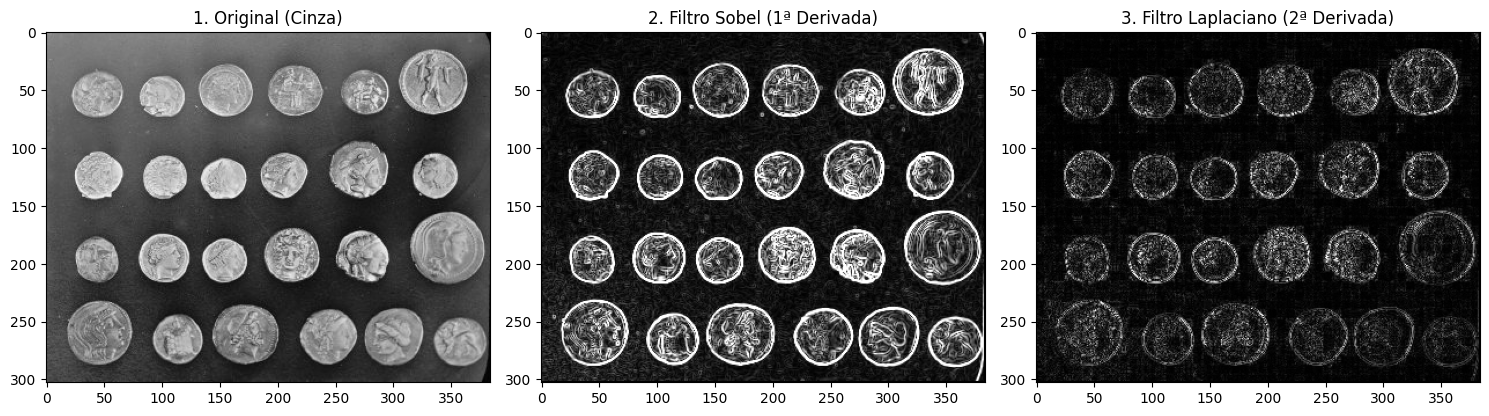

Filtros implementados com sucesso conforme o roteiro!


In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage import data  # Apenas para pegar uma imagem de exemplo válida

# --- PREPARAÇÃO DA IMAGEM ---
# O roteiro recomenda imagens de sementes (Saúde, 2019).
# Como não temos o arquivo físico, usaremos a imagem 'coins' que é similar.
imagem_array = data.coins()
imagem_original = Image.fromarray(imagem_array).convert("L")

# --- PASSO 1: FILTRO SOBEL (Primeira Derivada) ---
# O filtro Sobel é focado no realce de bordas via primeira derivada.
def aplicar_sobel(imagem):
    img_array = np.array(imagem, dtype=float)
    linhas, colunas = img_array.shape

    # Máscaras de Sobel (Eixos X e Y)
    gx_mask = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    gy_mask = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    sobel_img = np.zeros((linhas, colunas))

    for i in range(1, linhas - 1):
        for j in range(1, colunas - 1):
            vizinhanca = img_array[i-1:i+2, j-1:j+2]
            # Cálculo da primeira derivada
            gx = np.sum(gx_mask * vizinhanca)
            gy = np.sum(gy_mask * vizinhanca)
            sobel_img[i, j] = np.sqrt(gx**2 + gy**2)

    return np.uint8(np.clip(sobel_img, 0, 255))

# --- PASSO 2: FILTRO LAPLACIANO (Segunda Derivada) ---
# O Laplaciano detecta bordas pela diferença do pixel com a média dos vizinhos.
def aplicar_laplaciano(imagem):
    img_array = np.array(imagem, dtype=float)
    linhas, colunas = img_array.shape

    # Máscara Laplaciana (Segunda Derivada)
    mask = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])

    laplace_img = np.zeros((linhas, colunas))

    for i in range(1, linhas - 1):
        for j in range(1, colunas - 1):
            vizinhanca = img_array[i-1:i+2, j-1:j+2]
            # Cálculo da segunda derivada
            laplace_img[i, j] = np.abs(np.sum(mask * vizinhanca))

    return np.uint8(np.clip(laplace_img, 0, 255))

# --- EXECUÇÃO E EXIBIÇÃO ---
# Processando conforme o checklist do roteiro
resultado_sobel = aplicar_sobel(imagem_original)
resultado_laplace = aplicar_laplaciano(imagem_original)

# Plotando os resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("1. Original (Cinza)")
plt.imshow(imagem_original, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("2. Filtro Sobel (1ª Derivada)")
plt.imshow(resultado_sobel, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("3. Filtro Laplaciano (2ª Derivada)")
plt.imshow(resultado_laplace, cmap='gray')

plt.tight_layout()
plt.show()

print("Filtros implementados com sucesso conforme o roteiro!")